In [1]:
import json
import importlib
import data_analysis.utils.comparison_utils as comparison_utils
from data_analysis.utils.comparison_utils import degradation_summary, plot_degradation, plot_corruption_category, show_corruption_comparison
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

results_base_folder = "../results/"

# ImageNet-1k (downsampled) vs ImageNet-R
Here we compare the metrics of a model evaluated on ImageNet-1k (downsampled) and ImageNet-R. The metrics are stored in JSON files, and we will load them, compute the differences, and rank the metrics by their delta values.

In [2]:
# Se disponibile, useremo scipy per t-quantili; altrimenti fallback bootstrap.
try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False
# opzionale: seaborn per estetica (se non presente funziona lo stesso)
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    pass

baseline_path = results_base_folder + "ImageNetR/baseline_metrics.json"
drift_path    = results_base_folder + "ImageNetR/drift_metrics.json"

# Carico json
with open(baseline_path, "r") as f:
    metrics_1k = json.load(f)
with open(drift_path, "r") as f:
    metrics_r = json.load(f)

In [3]:
alpha = 0.05
n_boot = 5000  # bootstrap iterations for delta CI (aumenta per maggiore precisione)

def bootstrap_delta_ci(arr1, arr2, alpha=0.05, n_boot=2000, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    arr1 = np.asarray(arr1, dtype=float)
    arr2 = np.asarray(arr2, dtype=float)
    n1 = len(arr1)
    n2 = len(arr2)
    if n1 == 0 or n2 == 0:
        return np.nan, np.nan, np.nan
    boot_diffs = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        s1 = rng.choice(arr1, size=n1, replace=True)
        s2 = rng.choice(arr2, size=n2, replace=True)
        boot_diffs[i] = s1.mean() - s2.mean()
    lo = np.percentile(boot_diffs, 100 * (alpha/2))
    hi = np.percentile(boot_diffs, 100 * (1 - alpha/2))
    return boot_diffs.mean(), lo, hi

In [4]:
def stats_from_values_list(values):
    arr = np.array(values, dtype=float)
    n = len(arr)
    mean = arr.mean() if n>0 else np.nan
    std = arr.std(ddof=1) if n>1 else 0.0
    return mean, std, n, arr

def welch_delta_ci(m1, s1, n1, m2, s2, n2, alpha=0.05):
    # stima standard error del delta (indipendenti)
    se2 = (s1*s1)/n1 + (s2*s2)/n2
    if se2 <= 0:
        # nessuna variabilità stimabile -> CI puntuale
        delta = m1 - m2
        return delta, delta, delta
    se = np.sqrt(se2)
    # df di Welch-Satterthwaite
    num = se2**2
    denom = 0.0
    if n1 > 1:
        denom += ((s1*s1)/n1)**2 / (n1 - 1)
    if n2 > 1:
        denom += ((s2*s2)/n2)**2 / (n2 - 1)
    if denom <= 0 or not SCIPY_AVAILABLE:
        # non possiamo usare la formula del df correttamente (o manca scipy) -> fallback a bootstrap
        return None
    df = num / denom
    tcrit = stats.t.ppf(1 - alpha/2, df)
    delta = m1 - m2
    margin = tcrit * se
    return delta, delta - margin, delta + margin


In [5]:
summary = []
for metric in metrics_1k.keys():
    b = metrics_1k[metric]
    d = metrics_r.get(metric)
    if d is None:
        continue

    m1, s1, n1, arr1 = stats_from_values_list(b.get("values", []))
    m2, s2, n2, arr2 = stats_from_values_list(d.get("values", []))

    # prova metodo di Welch (t) se possibile
    welch_res = None
    if SCIPY_AVAILABLE and n1 > 0 and n2 > 0:
        welch_res = welch_delta_ci(m1, s1, n1, m2, s2, n2, alpha=alpha)
    if welch_res is not None:
        if welch_res is not None and isinstance(welch_res, tuple):
            delta_mean, ci_lo, ci_hi = welch_res
        else:
            delta_mean, ci_lo, ci_hi = welch_res
    else:
        # fallback bootstrap: se le run sono allineate (stessa lunghezza) usiamo paired bootstrap
        paired = (len(arr1) == len(arr2) and len(arr1) > 0)
        delta_mean, ci_lo, ci_hi = bootstrap_delta_ci(arr1, arr2, alpha=alpha, paired=paired, n_boot=2000)

    delta_point = m1 - m2
    significant = not (ci_lo <= 0 <= ci_hi)
    summary.append({
        "metric": metric,
        "baseline_mean": m1,
        "baseline_std": s1,
        "baseline_n": n1,
        "drift_mean": m2,
        "drift_std": s2,
        "drift_n": n2,
        "delta_mean": delta_point,
        "delta_ci_lo": ci_lo,
        "delta_ci_hi": ci_hi,
        "significant": significant
    })

# ordina per delta_mean decrescente
summary_sorted = sorted(summary, key=lambda x: x["delta_mean"], reverse=True)

# stampa tabellare sintetica
print(f"{'metric':30s} {'base (mean±CI)':30s} {'drift (mean±CI)':30s} {'delta (mean±CI)':30s} {'sig'}")
for row in summary_sorted:
    m = row["metric"]
    b_str = f"{row['baseline_mean']:.4f} (n={row['baseline_n']})"
    d_str = f"{row['drift_mean']:.4f} (n={row['drift_n']})"
    delta_str = f"{row['delta_mean']:.4f} [{row['delta_ci_lo']:.4f}, {row['delta_ci_hi']:.4f}]"
    sig = "YES" if row["significant"] else "no"
    print(f"{m:30s} {b_str:30s} {d_str:30s} {delta_str:30s} {sig}")


metric                         base (mean±CI)                 drift (mean±CI)                delta (mean±CI)                sig
cohen_kappa                    0.8426 (n=5)                   0.3021 (n=5)                   0.5404 [0.5390, 0.5419]        YES
accuracy                       0.8433 (n=5)                   0.3034 (n=5)                   0.5398 [0.5383, 0.5413]        YES
balanced_accuracy              0.8433 (n=5)                   0.3034 (n=5)                   0.5398 [0.5383, 0.5413]        YES
recall_weighted                0.8433 (n=5)                   0.3034 (n=5)                   0.5398 [0.5383, 0.5413]        YES
precision_micro                0.8433 (n=5)                   0.3034 (n=5)                   0.5398 [0.5383, 0.5413]        YES
recall_micro                   0.8433 (n=5)                   0.3034 (n=5)                   0.5398 [0.5383, 0.5413]        YES
f1_micro                       0.8433 (n=5)                   0.3034 (n=5)                   0.5398 [0.5

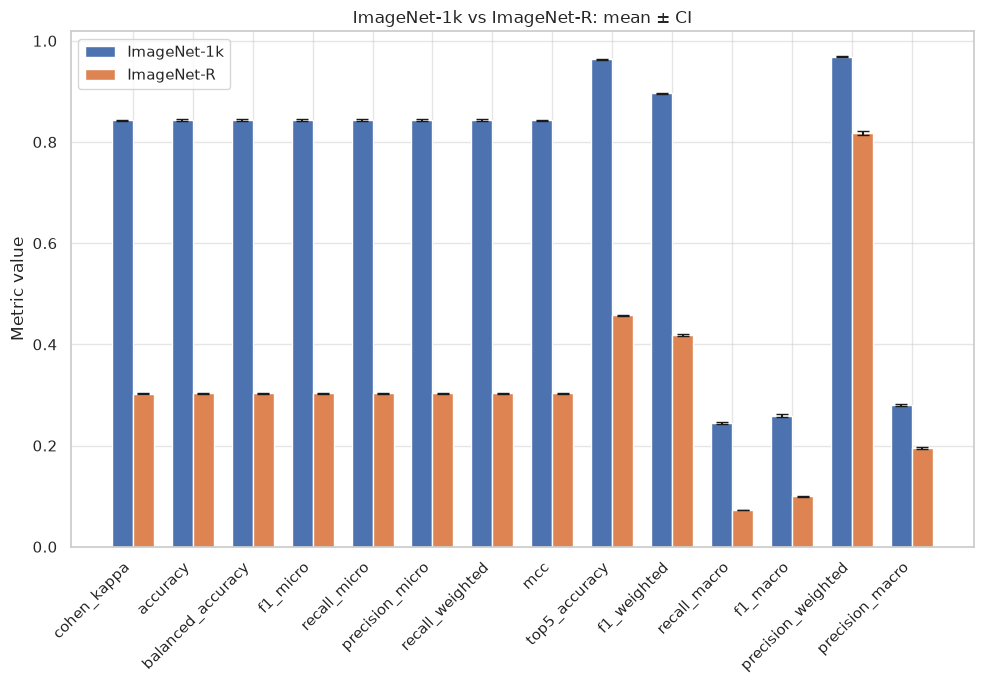

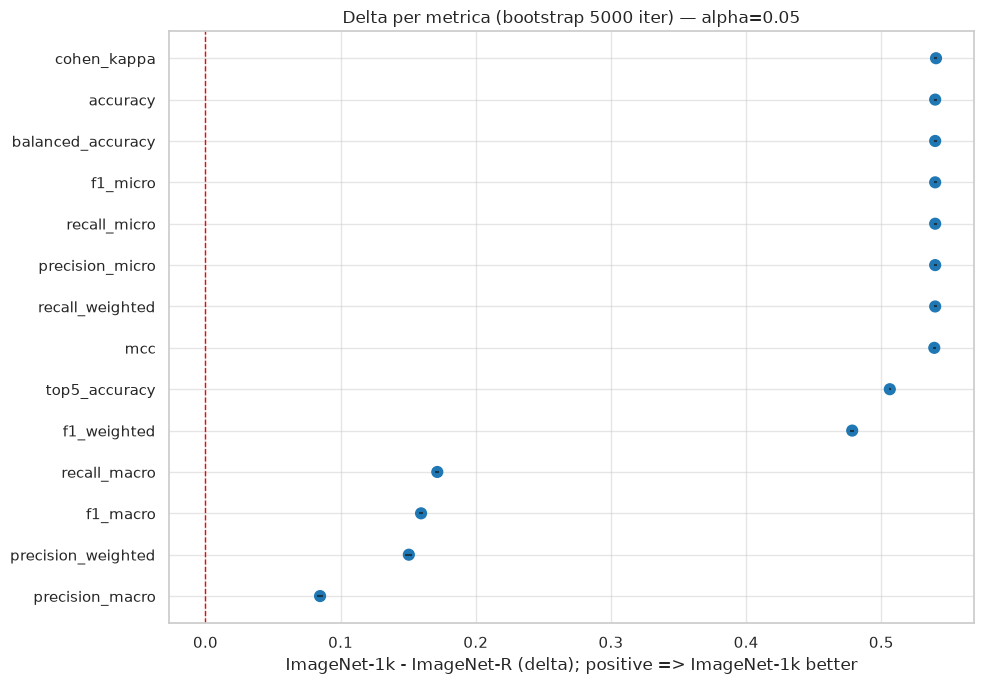

In [6]:

# Costruisco DataFrame con tutte le metriche presenti in entrambi
metrics = sorted(set(metrics_1k.keys()).intersection(metrics_r.keys()))
rows = []
for m in metrics:
    b = metrics_1k[m]
    d = metrics_r[m]
    b_mean = b.get("mean", np.nan)
    b_lo = b.get("ci_lower", b_mean)
    b_hi = b.get("ci_upper", b_mean)
    d_mean = d.get("mean", np.nan)
    d_lo = d.get("ci_lower", d_mean)
    d_hi = d.get("ci_upper", d_mean)
    b_vals = b.get("values", [b_mean])
    d_vals = d.get("values", [d_mean])
    delta_point = b_mean - d_mean
    delta_mean_boot, delta_lo_boot, delta_hi_boot = bootstrap_delta_ci(b_vals, d_vals, alpha=alpha, n_boot=n_boot)
    significant = not (delta_lo_boot <= 0 <= delta_hi_boot)
    rows.append({
        "metric": m,
        "base_mean": b_mean, "base_lo": b_lo, "base_hi": b_hi,
        "drift_mean": d_mean, "drift_lo": d_lo, "drift_hi": d_hi,
        "delta_point": delta_point,
        "delta_mean_boot": delta_mean_boot, "delta_lo_boot": delta_lo_boot, "delta_hi_boot": delta_hi_boot,
        "significant": significant
    })

df = pd.DataFrame(rows)
# Ordina per delta decrescente
df = df.sort_values("delta_point", ascending=False).reset_index(drop=True)

# --- Plot 1: baseline vs drift (side-by-side bars with CI) ---
fig, ax = plt.subplots(figsize=(10, max(4, 0.5 * len(df))))
x = np.arange(len(df))
width = 0.35

# errorbars: calcolo margine (asymmetric)
base_err_low = df["base_mean"] - df["base_lo"]
base_err_high = df["base_hi"] - df["base_mean"]
drift_err_low = df["drift_mean"] - df["drift_lo"]
drift_err_high = df["drift_hi"] - df["drift_mean"]

# se le CI sono puntuali (0 width) matplotlib accetta 0
ax.bar(x - width/2, df["base_mean"], width, label="ImageNet-1k", yerr=[base_err_low.values, base_err_high.values], capsize=4)
ax.bar(x + width/2, df["drift_mean"], width, label="ImageNet-R", yerr=[drift_err_low.values, drift_err_high.values], capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(df["metric"], rotation=45, ha="right")
ax.set_ylabel("Metric value")
ax.set_title("ImageNet-1k vs ImageNet-R: mean ± CI")
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Delta with bootstrap CI (horizontal bar) ---
fig, ax = plt.subplots(figsize=(10, max(4, 0.5 * len(df))))
y = np.arange(len(df))
deltas = df["delta_point"].values
# bootstrap CI margins
delta_lo = df["delta_mean_boot"] - df["delta_lo_boot"]  # mean - lo
delta_hi = df["delta_hi_boot"] - df["delta_mean_boot"]  # hi - mean
# But better to show the actual lo/hi in absolute coordinates:
ci_lo_abs = df["delta_lo_boot"].values
ci_hi_abs = df["delta_hi_boot"].values

colors = ["tab:blue" if sig else "lightgray" for sig in df["significant"]]

ax.hlines(y, ci_lo_abs, ci_hi_abs, color='k', alpha=0.7)
ax.scatter(deltas, y, color=colors, s=60)
ax.set_yticks(y)
ax.set_yticklabels(df["metric"])
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel("ImageNet-1k - ImageNet-R (delta); positive => ImageNet-1k better")
ax.set_title(f"Delta per metrica (bootstrap {n_boot} iter) — alpha={alpha}")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ImageNet-1k vs ImageNet-C
Here we compare the metrics of a model evaluated on ImageNet-1k and ImageNet-C. The metrics are stored in JSON files. We will evaluate the different metrics at the varying levels of corruption severity and rank the metrics by their delta values. We will also visualize the results using plots.

In [7]:
idx = 10

## Noise
Here we evaluate the metrics of a model on ImageNet-1k and ImageNet-C with noise corruption. The different types of noise corruption are: gaussian_noise, shot_noise, and impulse_noise.

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/categories/noise_accuracy.png


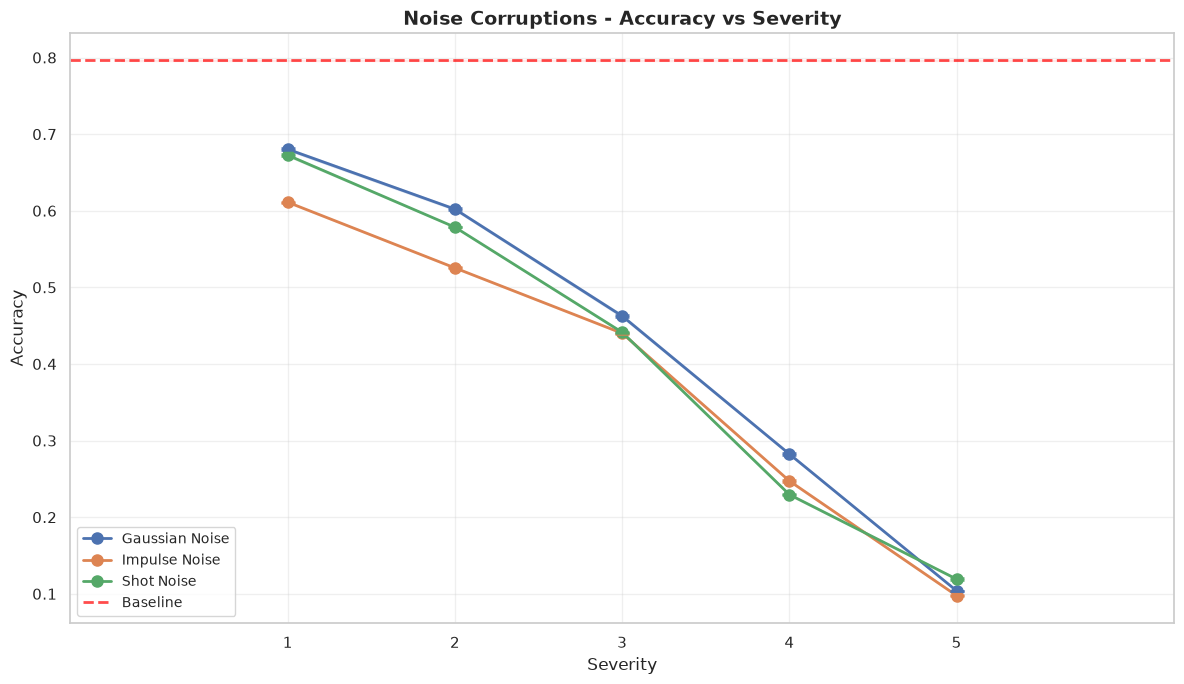

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/degradation/noise_accuracy_degradation.png


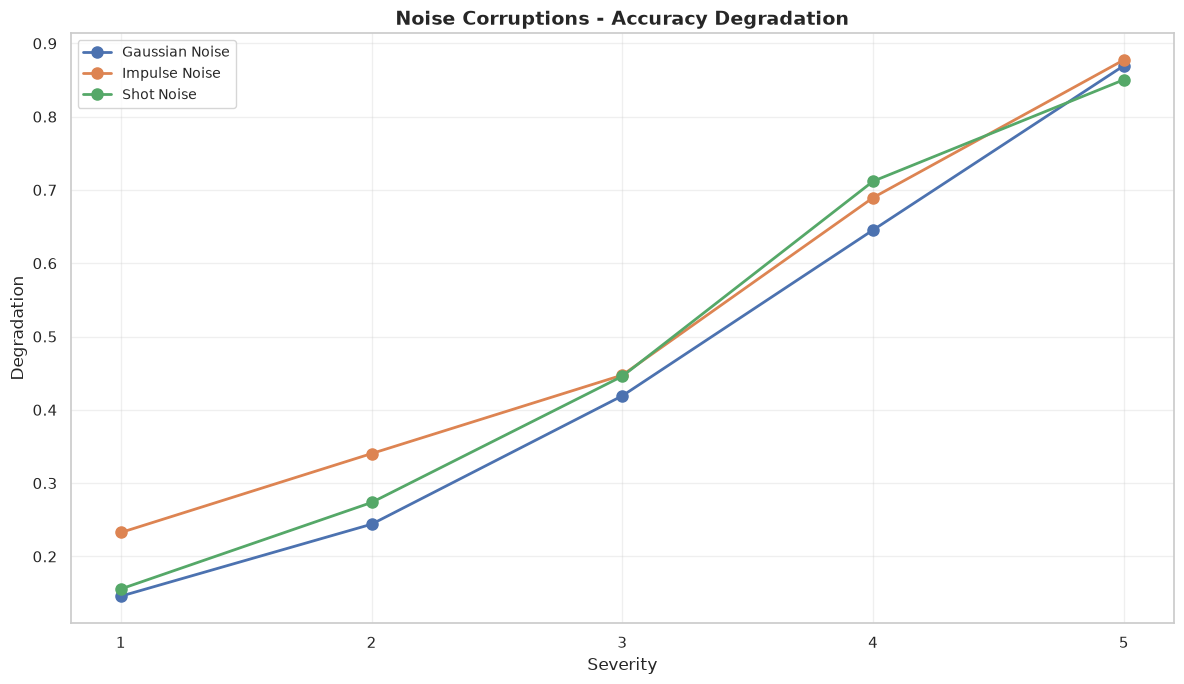

,corruption_type,AUC,slope,R_squared
0,gaussian_noise,0.535206,0.184893,0.979393
2,shot_noise,0.512519,0.182769,0.983590
1,impulse_noise,0.482528,0.163862,0.970980


In [8]:
plot_corruption_category("../results/ImageNetC", category='noise', metric_name='accuracy')
# AUC delle robustness (media rapporto accuracy a un severity level e baseline), non della degradation
summary_noise = degradation_summary("../results/ImageNetC", metric_name='accuracy', category='noise',use_robustness=True)
plot_degradation(category='noise', metric_name='accuracy')
summary_noise

### Gaussian Noise

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/image_comparisons/gaussian_noise_sample_10.png


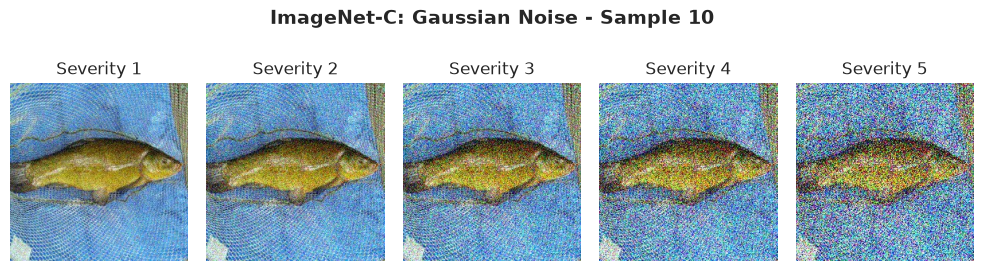

In [9]:
# show example of image with gaussian blur corruption at different severity levels
show_corruption_comparison("gaussian_noise", random_idx=False, sample_idx= idx)

### Shot Noise

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/image_comparisons/shot_noise_sample_10.png


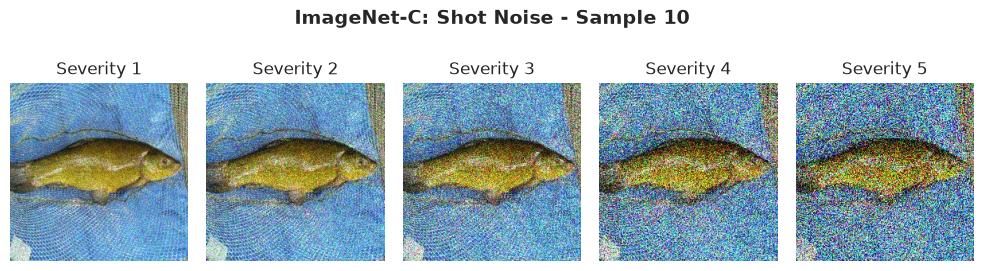

In [10]:
# show example of image with shot noise corruption at different severity levels
show_corruption_comparison("shot_noise", random_idx=False, sample_idx= idx)

### Impulse Noise

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/image_comparisons/impulse_noise_sample_10.png


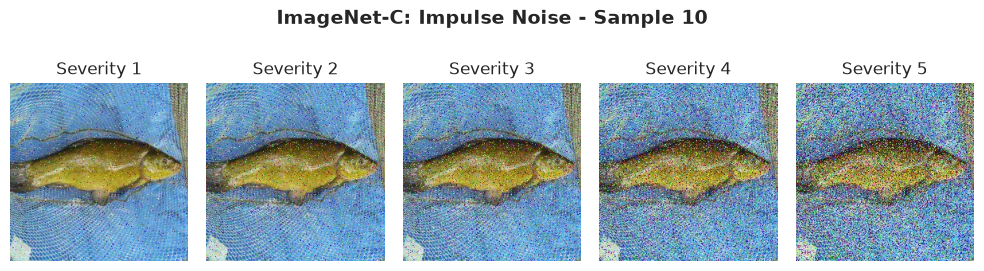

In [11]:
# show example of image with impulse noise corruption at different severity levels
show_corruption_comparison("impulse_noise", random_idx=False, sample_idx= idx)

## Blur
Here we evaluate the metrics of a model on ImageNet-1k and ImageNet-C with blur corruption. The different types of blur corruption are: defocus_blur, glass_blur, motion_blur, and zoom_blur.

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/categories/blur_accuracy.png


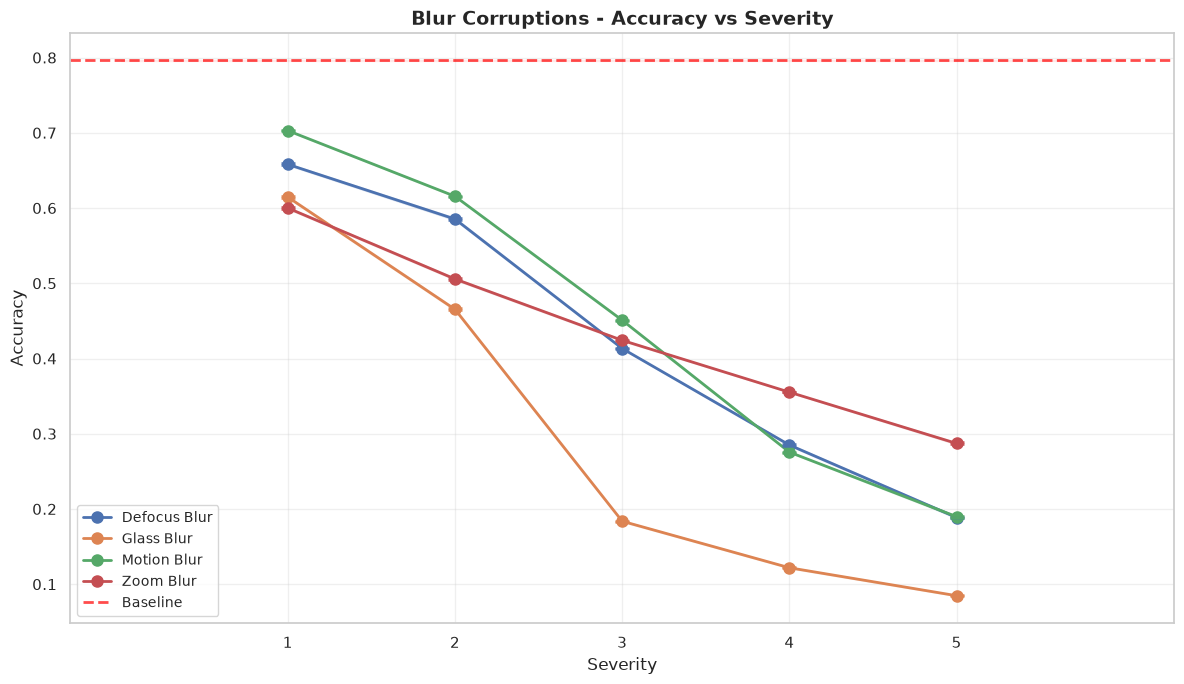

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/degradation/blur_accuracy_degradation.png


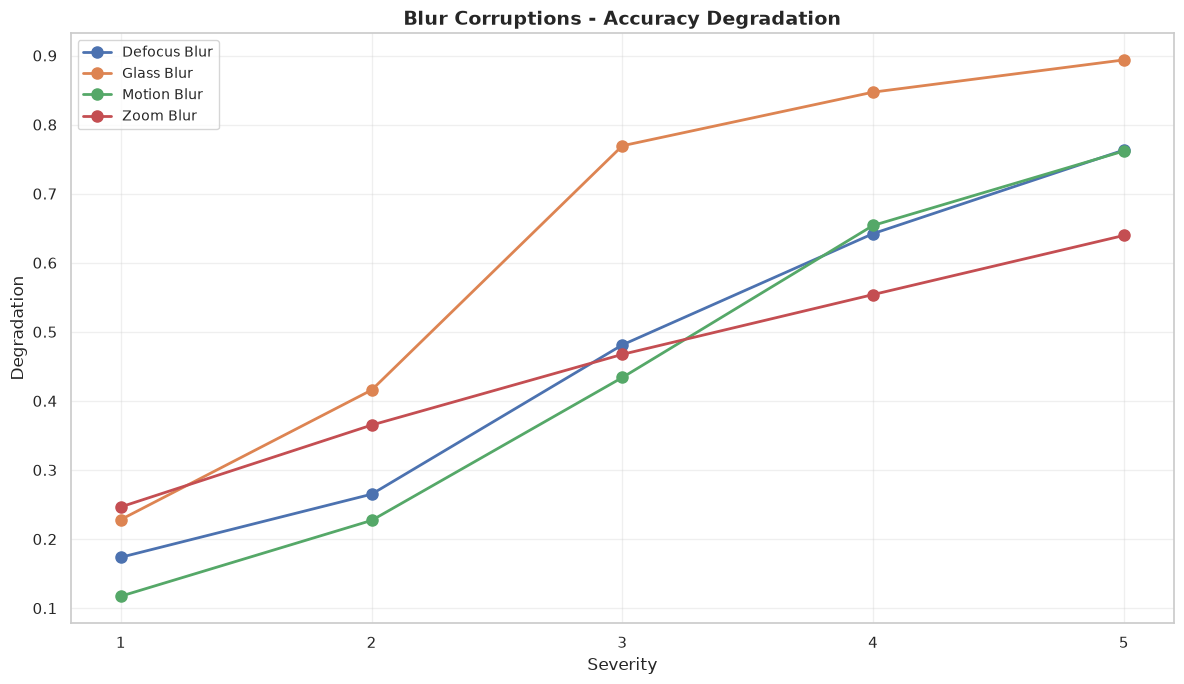

,corruption_type,AUC,slope,R_squared
2,motion_blur,0.561179,0.171572,0.985192
3,zoom_blur,0.545493,0.097476,0.994757
0,defocus_blur,0.534979,0.155609,0.986706
1,glass_blur,0.369184,0.176186,0.904344


In [12]:
plot_corruption_category("../results/ImageNetC", category='blur', metric_name='accuracy')
summary_blur = degradation_summary("../results/ImageNetC", metric_name='accuracy', category='blur',use_robustness=True)
plot_degradation(category='blur', metric_name='accuracy')
summary_blur

### Defocus Blur

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/image_comparisons/defocus_blur_sample_10.png


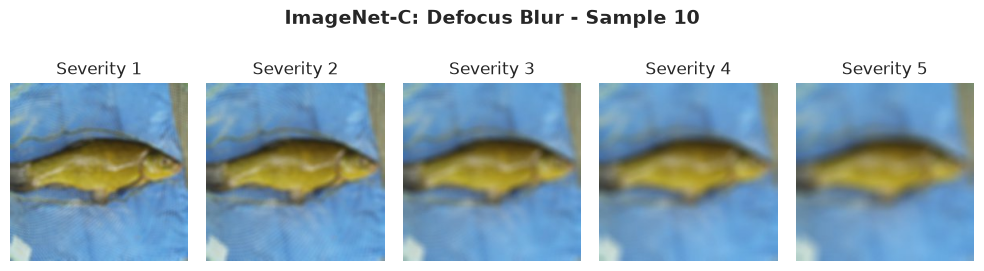

In [13]:
# show example of image with defocus blur corruption at different severity levels
show_corruption_comparison("defocus_blur", random_idx=False, sample_idx= idx)

### Glass Blur

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/image_comparisons/glass_blur_sample_10.png


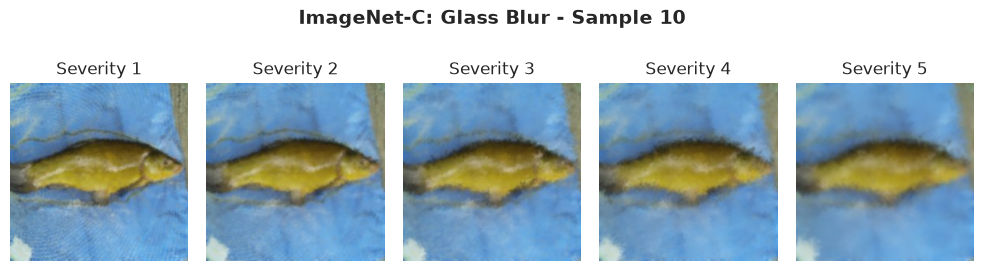

In [14]:
# show example of image with glass blur corruption at different severity levels
show_corruption_comparison("glass_blur", random_idx=False, sample_idx= idx)

### Motion Blur

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/image_comparisons/motion_blur_sample_10.png


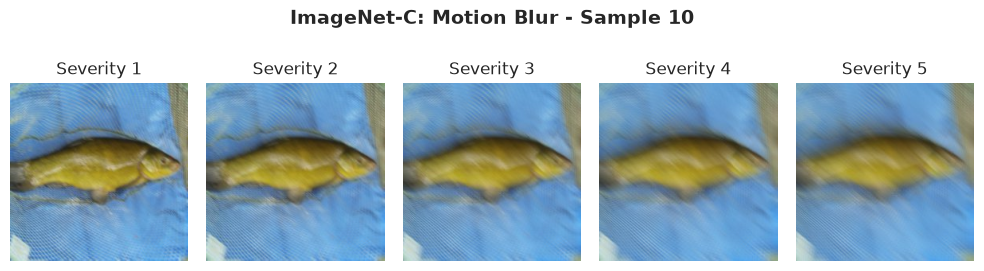

In [15]:
# show example of image with motion blur corruption at different severity levels
show_corruption_comparison("motion_blur", random_idx=False, sample_idx= idx)

### Zoom Blur

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/image_comparisons/zoom_blur_sample_10.png


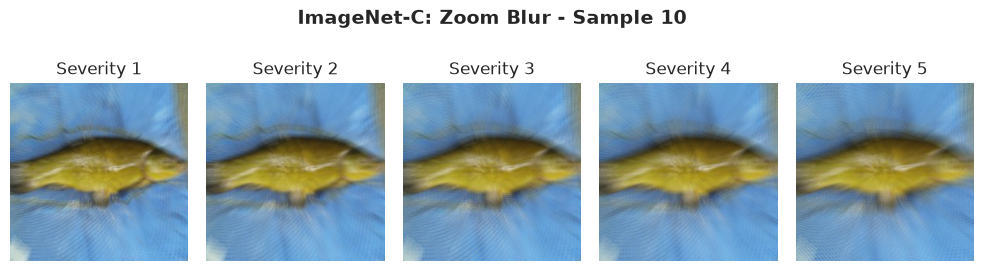

In [16]:
# show example of image with zoom blur corruption at different severity levels
show_corruption_comparison("zoom_blur", random_idx=False, sample_idx= idx)

## Weather
Here we evaluate the metrics of a model on ImageNet-1k and ImageNet-C with weather corruption. The different types of weather corruption are: snow, frost, fog, and brightness.

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/categories/weather_accuracy.png


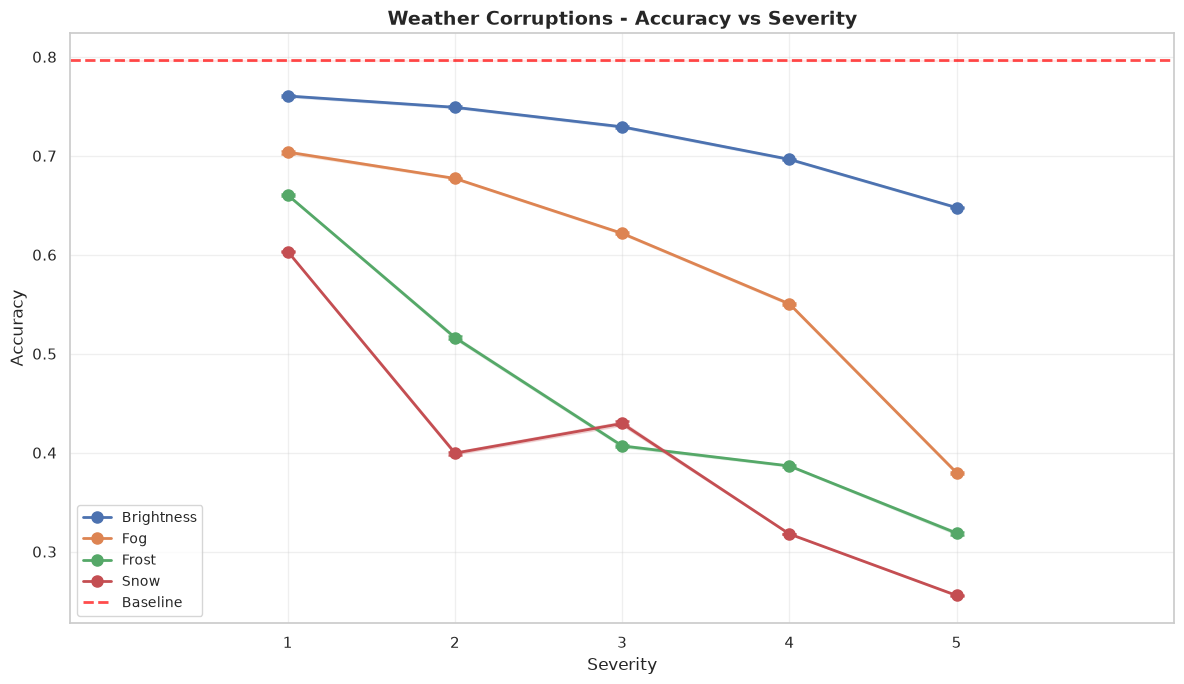

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/degradation/weather_accuracy_degradation.png


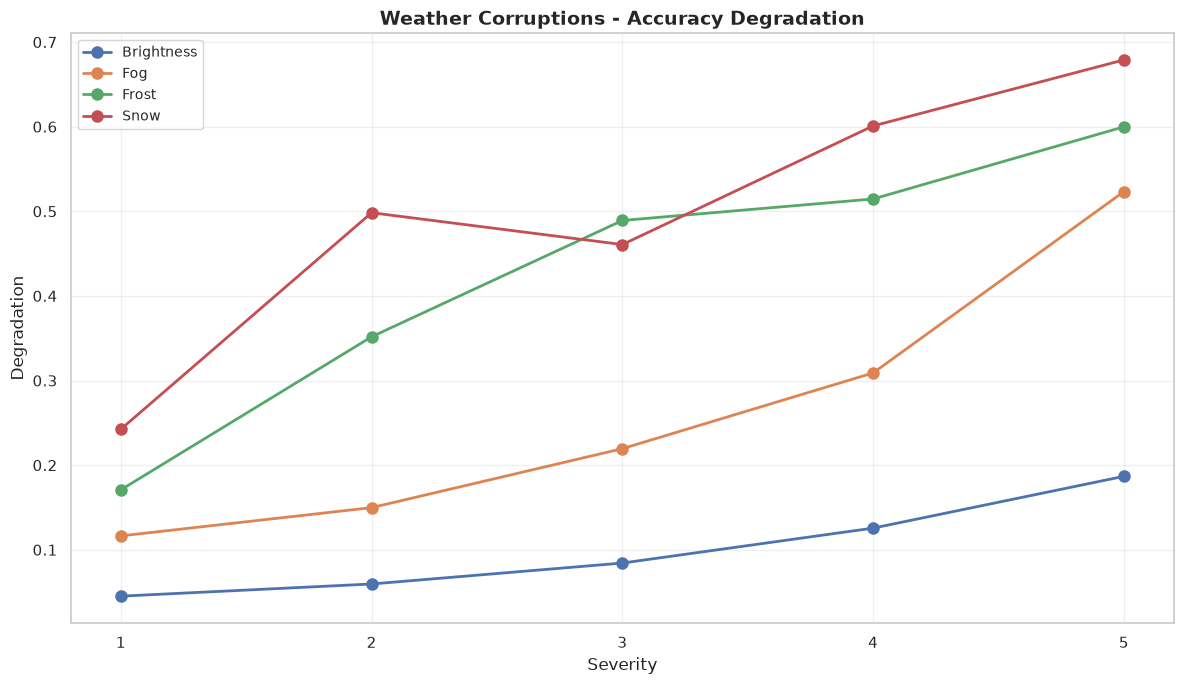

,corruption_type,AUC,slope,R_squared
0,brightness,0.899717,0.034920,0.932987
1,fog,0.736412,0.097285,0.892568
2,frost,0.574758,0.102072,0.924922
3,snow,0.503722,0.097529,0.865135


In [17]:
plot_corruption_category("../results/ImageNetC", category='weather', metric_name='accuracy')
summary_weather = degradation_summary("../results/ImageNetC", metric_name='accuracy', category='weather',use_robustness=True)
plot_degradation(category='weather', metric_name='accuracy')
summary_weather

### Brightness

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/image_comparisons/brightness_sample_10.png


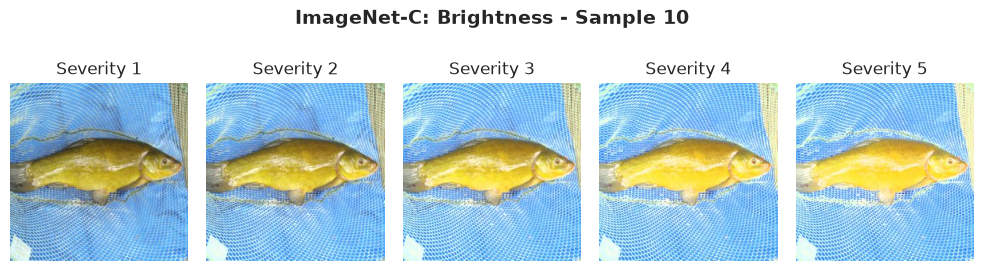

In [18]:
# show example of image with brightness corruption at different severity levels
show_corruption_comparison("brightness", random_idx=False, sample_idx= idx)

### Snow

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/image_comparisons/snow_sample_10.png


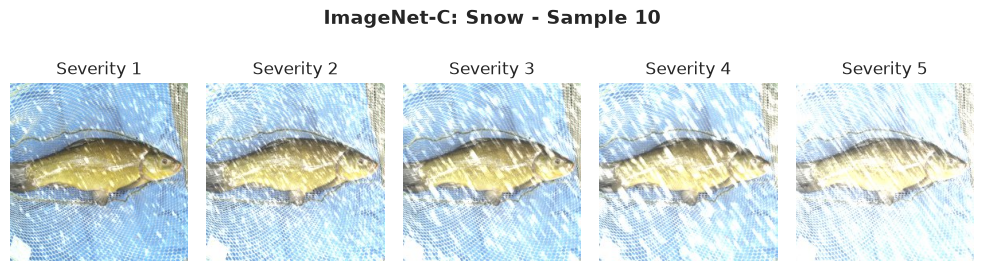

In [19]:
# show example of image with snow corruption at different severity levels
show_corruption_comparison("snow", random_idx=False, sample_idx= idx)

### Frost

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/image_comparisons/frost_sample_10.png


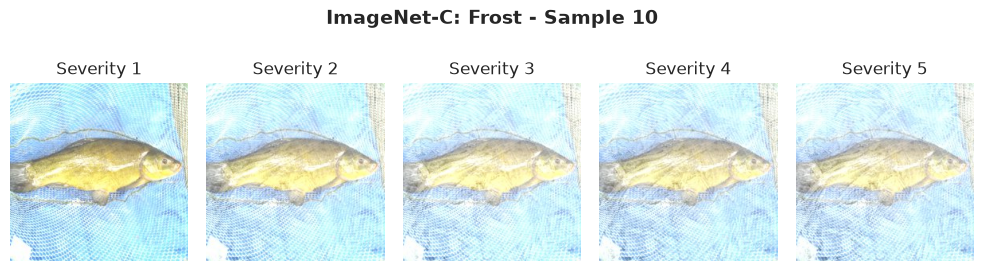

In [20]:
# show example of image with frost corruption at different severity levels
show_corruption_comparison("frost", random_idx=False, sample_idx= idx)

### Fog

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/image_comparisons/fog_sample_10.png


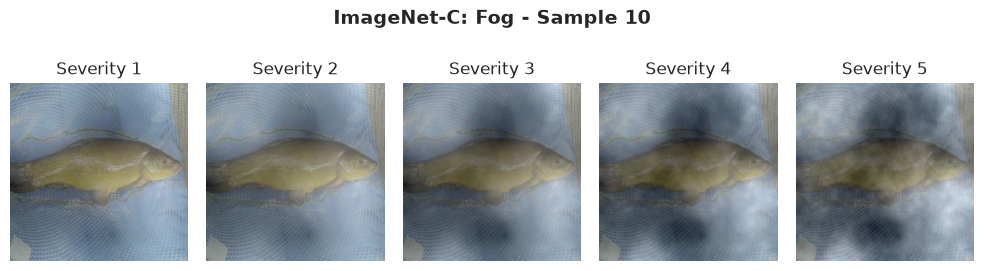

In [21]:
# show example of image with fog corruption at different severity levels
show_corruption_comparison("fog", random_idx=False, sample_idx= idx)

## Digital
Here we evaluate the metrics of a model on ImageNet-1k and ImageNet-C with digital corruption. The different types of digital corruption are: contrast, elastic_transform, pixelate, and jpeg_compression and brightness.

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/categories/digital_accuracy.png


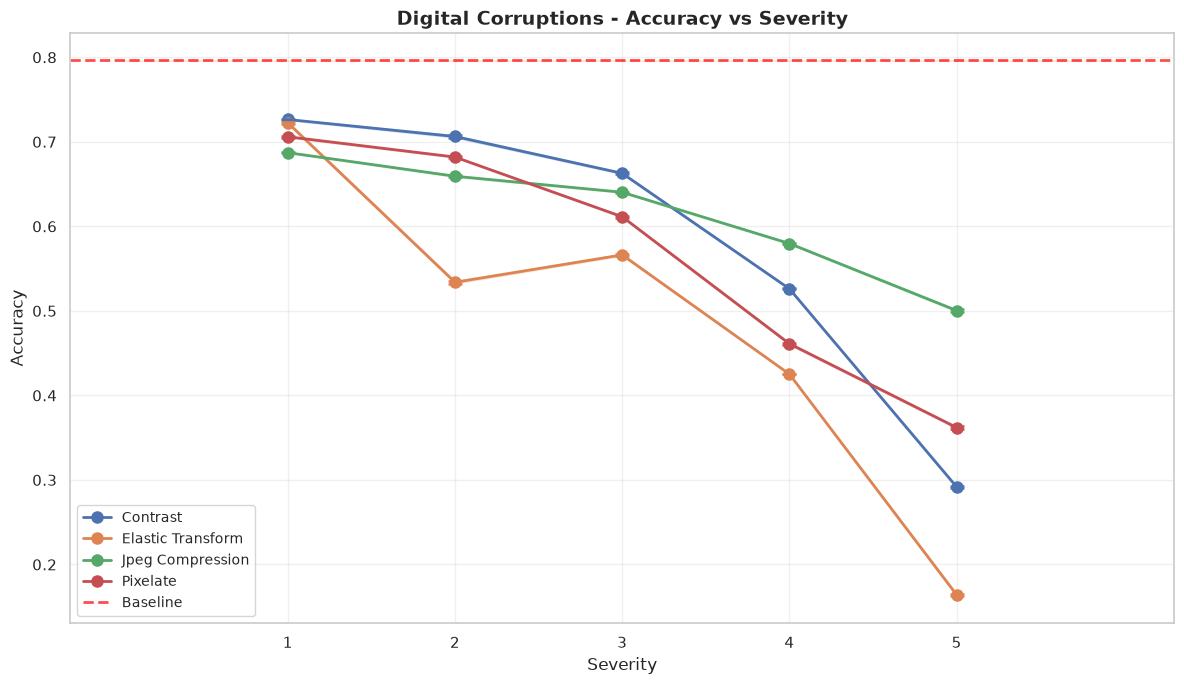

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/degradation/digital_accuracy_degradation.png


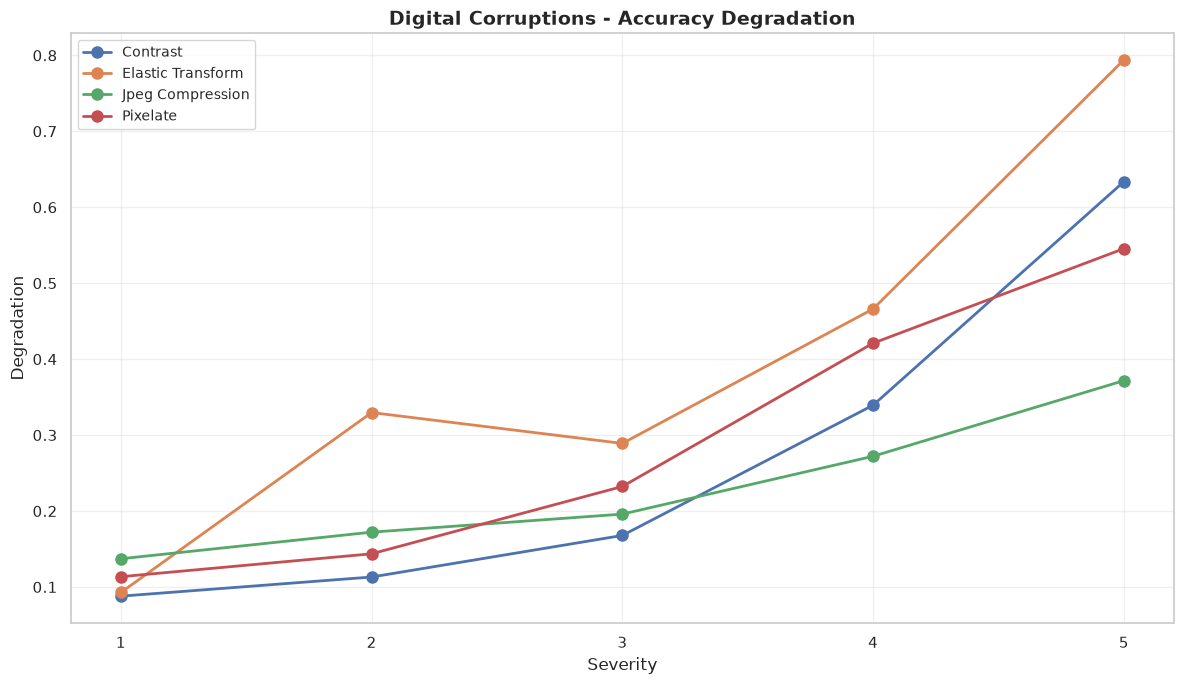

,corruption_type,AUC,slope,R_squared
2,jpeg_compression,0.770172,0.056896,0.925757
0,contrast,0.731614,0.131767,0.846042
3,pixelate,0.708785,0.114113,0.941701
1,elastic_transform,0.605682,0.153883,0.873604


In [22]:
plot_corruption_category("../results/ImageNetC", category='digital', metric_name='accuracy')
summary_digital = degradation_summary("../results/ImageNetC", metric_name='accuracy', category='digital',use_robustness=True)
plot_degradation(category='digital', metric_name='accuracy')
summary_digital

### Contrast

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/image_comparisons/contrast_sample_10.png


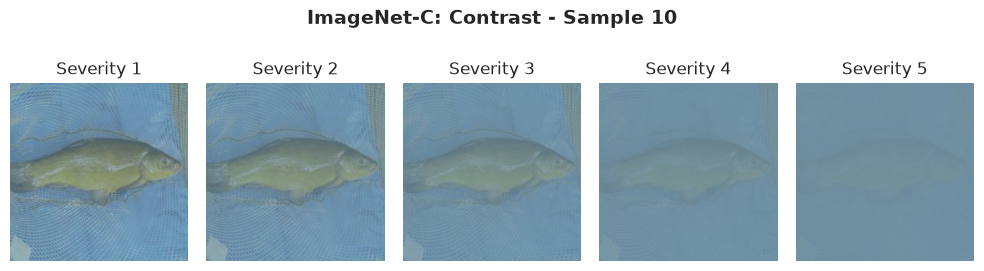

In [23]:
# show example of image with contrast corruption at different severity levels
show_corruption_comparison("contrast", random_idx=False, sample_idx= idx)

### Elastic transformation

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/image_comparisons/elastic_transform_sample_10.png


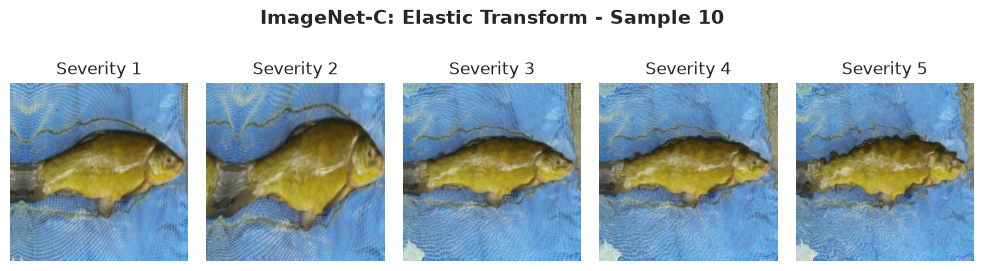

In [24]:
# show example of image with elastic_transform corruption at different severity levels
show_corruption_comparison("elastic_transform", random_idx=False, sample_idx= idx)

### Jpeg compression

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/image_comparisons/jpeg_compression_sample_10.png


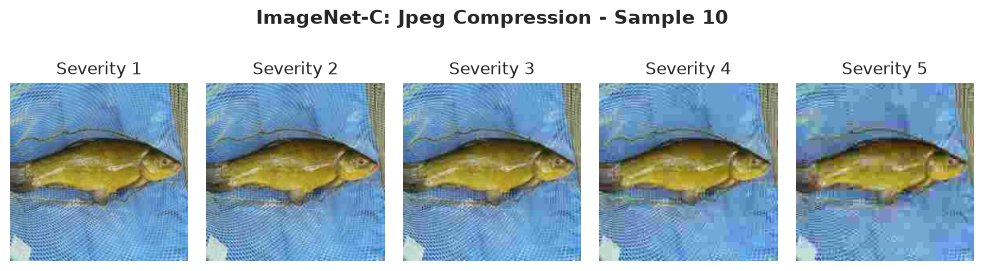

In [25]:
# show example of image with jpeg_compression corruption at different severity levels
show_corruption_comparison("jpeg_compression", random_idx=False, sample_idx= idx)

### Pixelate

Figure saved to /home/daniele/magistrale/DataDrift-Project/eda_outputs/plot_metrics/image_comparisons/pixelate_sample_10.png


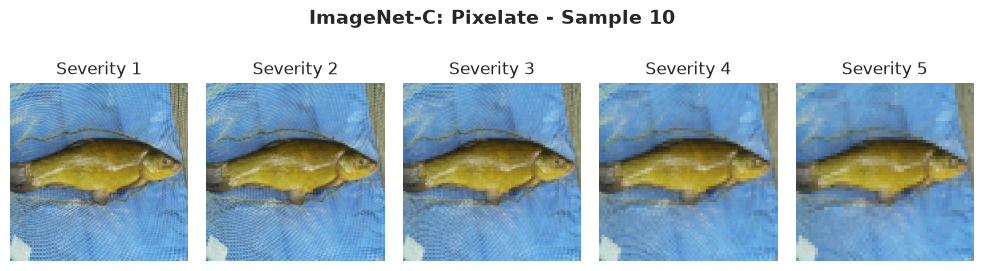

In [26]:
# show example of image with pixelate corruption at different severity levels
show_corruption_comparison("pixelate", random_idx=False, sample_idx= idx)

## Summary

In [27]:
# Tutte le corruzioni
summary_all = degradation_summary("../results/ImageNetC", metric_name='accuracy',use_robustness=True)
summary_all


,corruption_type,AUC,slope,R_squared
0,brightness,0.899717,0.034920,0.932987
9,jpeg_compression,0.770172,0.056896,0.925757
4,fog,0.736412,0.097285,0.892568
1,contrast,0.731614,0.131767,0.846042
11,pixelate,0.708785,0.114113,0.941701
3,elastic_transform,0.605682,0.153883,0.873604
5,frost,0.574758,0.102072,0.924922
10,motion_blur,0.561179,0.171572,0.985192
14,zoom_blur,0.545493,0.097476,0.994757
6,gaussian_noise,0.535206,0.184893,0.979393
